# 1. Imports and other

Ruta raíz del proyecto

In [1]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
print(PROJECT_ROOT)

c:\Users\Carlos\Documents\Ingenieria_informatica\Proyectos_datascience\3_prediccion_precios_casas


Añadir ruta raíz al sys, para que se puedan ocupar los archivos de src

In [2]:
import sys

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.utils import bar_plot_project
import seaborn as sns

Definir colores estandar para las visualizaciones

In [4]:
PROJECT_COLORS = ["#2DD61D", "#3410FF"]

Leer csv

In [5]:
df = pd.read_csv(PROJECT_ROOT / 'data' / 'raw' / 'train.csv')

Filas totales del DataFrame

In [6]:
TOTAL_ROWS = len(df)
TOTAL_ROWS

1460

# 2. General info

In [7]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [9]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


# 3. Raw EDA

# 3.1 Nulls

Crear DataFrame para identificar features con nulos

In [10]:
df_nulls = pd.DataFrame()

for col in df.columns:
    num_nulls = df[col].isna().sum()
    num_nulls_pct = np.round((num_nulls / TOTAL_ROWS) * 100, 2)

    if num_nulls != 0:
        df_nulls_to_add = pd.DataFrame({
            'Column': [col],
            'Nulls': [num_nulls],
            'Nullspct': [num_nulls_pct]
        })

        df_nulls = pd.concat([df_nulls, df_nulls_to_add])

df_nulls = df_nulls.sort_values(by='Nullspct', ascending=False).reset_index(drop=True)
df_nulls

,Column,Nulls,Nullspct
0,PoolQC,1453,99.52
1,MiscFeature,1406,96.30
2,Alley,1369,93.77
3,Fence,1179,80.75
4,MasVnrType,872,59.73
5,FireplaceQu,690,47.26
6,LotFrontage,259,17.74
7,GarageType,81,5.55
8,GarageYrBlt,81,5.55
9,GarageFinish,81,5.55


In [11]:
df['MasVnrType'].unique()

<StringArray>
['BrkFace', nan, 'Stone', 'BrkCmn']
Length: 4, dtype: str

Features que sus nulos significan auscencia:

- PoolQC
- MiscFeature
- Alley
- Fence
- MasVnrType/MasVnrArea
- FirePlaceQu
- GarageType/GarageYrBlt/GarageFinish/GarageQual/GarageCond
- BsmtExposure/BsmtFinType2/BsmtQual/BsmtCond/BsmtFinType1

Features que sus nulos son falta de información:

- LotFrontage
- Electrical

Ver que contienen los MasVnrArea que tienen NaN

In [12]:
df.loc[
    (df['MasVnrArea'].isna()),
    ['MasVnrType', 'MasVnrArea']
]

,MasVnrType,MasVnrArea
234,NaN,NaN
529,NaN,NaN
650,NaN,NaN
936,NaN,NaN
973,NaN,NaN
977,NaN,NaN
1243,NaN,NaN
1278,NaN,NaN


Ahora empezaremos a ver los features considerados más importantes a modo general

# 4. Select features (0 -> 14)

Seleccionar de los primeros 15 features, los más interesantes. Las que se encuentran son:

- MSSubClass
- MSZoning
- LotArea
- LotShape
- Utilities
- Neighborhood

In [13]:
df.iloc[:7, :15]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Somerst,Norm,Norm


# 5. MSSubClass

Primero veamos cuantas categorías tiene y cuales son

In [14]:
df['MSSubClass'].nunique()

15

In [15]:
df['MSSubClass'].unique()

array([ 60,  20,  70,  50, 190,  45,  90, 120,  30,  85,  80, 160,  75,
       180,  40])

Ver nulos

In [16]:
df['MSSubClass'].isna().sum()

np.int64(0)

Visualizar promedios de precio

In [17]:
group_mssubclass_mean_sales = df.groupby('MSSubClass')['SalePrice'].agg(['mean', 'count'])
group_mssubclass_mean_sales

,mean,count
MSSubClass,,
20,185224.811567,536
30,95829.724638,69
40,156125.000000,4
45,108591.666667,12
50,143302.972222,144
60,239948.501672,299
70,166772.416667,60
75,192437.500000,16
80,169736.551724,58


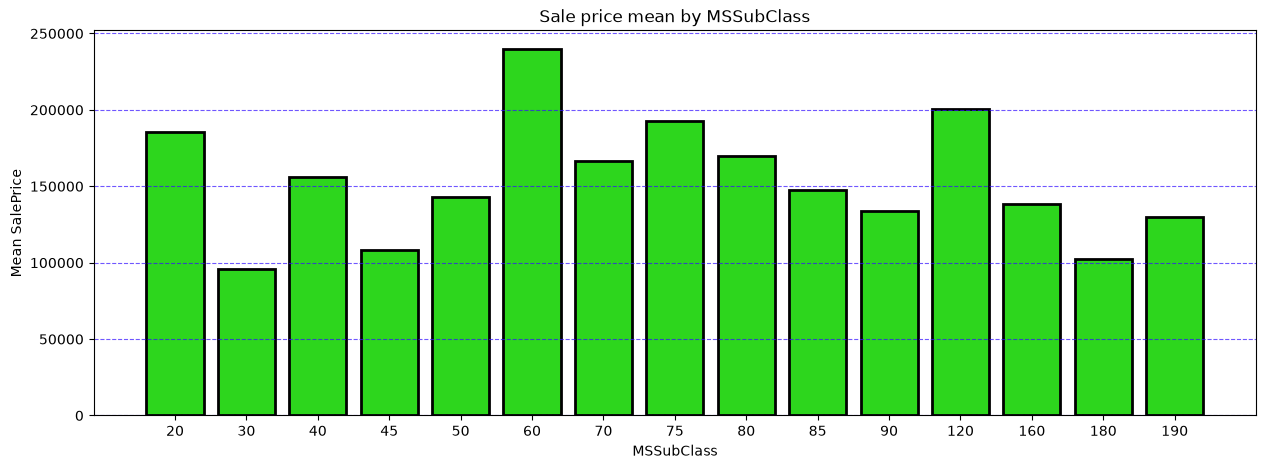

In [18]:
fig, ax = bar_plot_project(
    x=group_mssubclass_mean_sales.index.astype(str),
    y=group_mssubclass_mean_sales['mean'],
    title='Sale price mean by MSSubClass',
    x_label='MSSubClass',
    y_label='Mean SalePrice'
)

plt.show()

# 6. MSZoning

Categorías

In [19]:
df['MSZoning'].nunique()

5

In [20]:
df['MSZoning'].unique()

<StringArray>
['RL', 'RM', 'C (all)', 'FV', 'RH']
Length: 5, dtype: str

Nulos

In [21]:
df['MSZoning'].isna().sum()

np.int64(0)

Veamos efecto en SalePrice

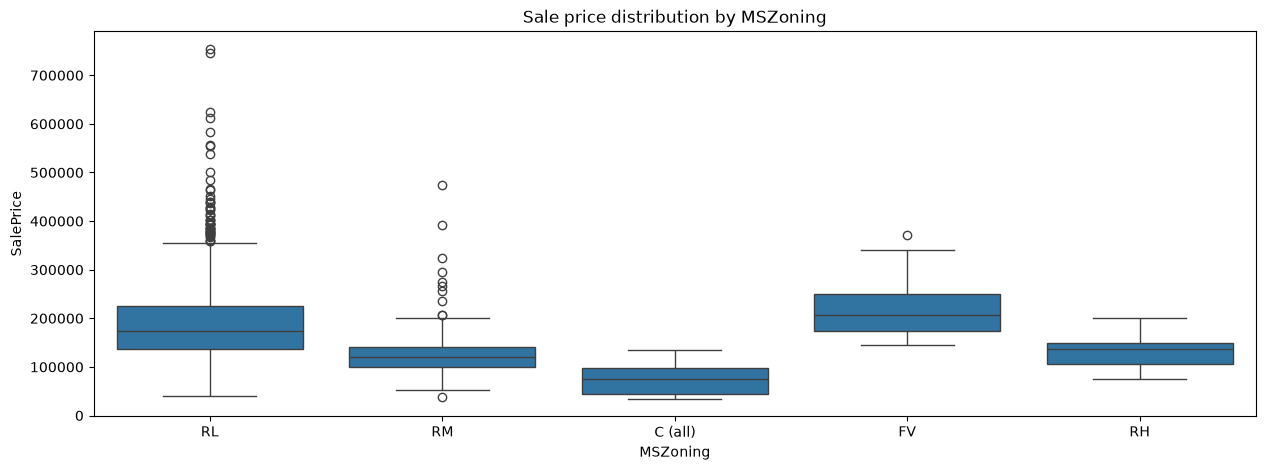

In [24]:
plt.figure(figsize=(15, 5))

sns.boxplot(data=df, x='MSZoning', y='SalePrice')

plt.xlabel('MSZoning')
plt.ylabel('SalePrice')

plt.title('Sale price distribution by MSZoning')

plt.show()